This notebook was used for experimentation and prototyping.
The final implementation is provided in train.py.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands/SeaLake
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands/Highway
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands/River
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands/Pasture
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands/Industrial
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands/Residential
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands/PermanentCrop
/kaggle/input/competit

In [2]:
DATA_DIR = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT"

In [3]:
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch import nn, optim
from torch.utils.data import DataLoader

# Path
DATA_DIR = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT"

# Transforms (IMPORTANT)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dataset
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

# Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

# Model
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Validation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", correct / total)

# Save model
torch.save(model.state_dict(), "model.pth")

Epoch 1, Loss: 298.0127
Epoch 2, Loss: 160.6212
Epoch 3, Loss: 138.8791
Validation Accuracy: 0.9437037037037037


In [4]:
import os

base = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak"

for root, dirs, files in os.walk(base):
    for f in files:
        if "test" in f.lower():
            print(os.path.join(root, f))

/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSATallBands/test.csv
/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/test.csv


In [5]:
import pandas as pd

test_path = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/test.csv"
test_df = pd.read_csv(test_path)

print(test_df.head())
print(test_df.columns)

   Unnamed: 0                          Filename  Label    ClassName
0        2438    AnnualCrop/AnnualCrop_1275.jpg      0   AnnualCrop
1        1018   Residential/Residential_504.jpg      7  Residential
2           3           Pasture/Pasture_787.jpg      5      Pasture
3        1011  Residential/Residential_1575.jpg      7  Residential
4          47           Pasture/Pasture_473.jpg      5      Pasture
Index(['Unnamed: 0', 'Filename', 'Label', 'ClassName'], dtype='object')


In [9]:
import torch
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import os

# Load model
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load("model.pth"))
model.eval()

classes = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load test CSV
test_path = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/test.csv"
test_df = pd.read_csv(test_path)

image_base = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT"

predictions = []

for img_name in test_df["Filename"]:
    img_path = os.path.join(image_base, img_name)

    image = Image.open(img_path).convert("RGB")
    img = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = model(img)
        pred = output.argmax(1).item()

    predictions.append(pred)  # numeric label

# Create submission
submission = pd.DataFrame({
    "Filename": test_df["Filename"],
    "Label": predictions
})

submission.to_csv("solution.csv", index=False)

print("Submission ready!")

Submission ready!


In [10]:
for i in range(5):
    print(test_df["Filename"][i], "→", predictions[i])

AnnualCrop/AnnualCrop_1275.jpg → 0
Residential/Residential_504.jpg → 7
Pasture/Pasture_787.jpg → 5
Residential/Residential_1575.jpg → 7
Pasture/Pasture_473.jpg → 5


In [11]:
print(submission.head())

                           Filename  Label
0    AnnualCrop/AnnualCrop_1275.jpg      0
1   Residential/Residential_504.jpg      7
2           Pasture/Pasture_787.jpg      5
3  Residential/Residential_1575.jpg      7
4           Pasture/Pasture_473.jpg      5


In [12]:
submission.to_csv("solution.csv", index=False)

In [13]:
submission.to_csv("solution_TheCodeHers.csv", index=False)

In [15]:
import pandas as pd

df = pd.read_csv("solution_TheCodeHers.csv")
print(df.head())
print(df.shape)

                           Filename  Label
0    AnnualCrop/AnnualCrop_1275.jpg      0
1   Residential/Residential_504.jpg      7
2           Pasture/Pasture_787.jpg      5
3  Residential/Residential_1575.jpg      7
4           Pasture/Pasture_473.jpg      5
(2700, 2)


In [16]:
print(df.isnull().sum())

Filename    0
Label       0
dtype: int64


In [17]:
print(df["Label"].unique())

[0 7 5 6 8 2 9 1 3 4]


In [19]:
test_df = pd.read_csv("/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/test.csv")

print(len(test_df), len(df))

2700 2700


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

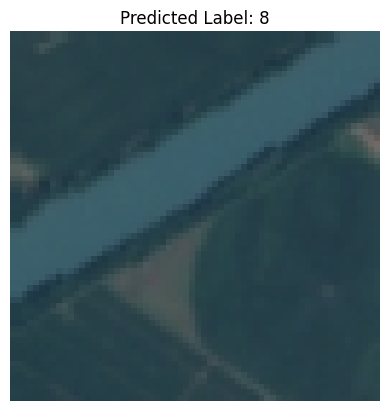

In [21]:
import random
from PIL import Image
import matplotlib.pyplot as plt

idx = random.randint(0, len(df)-1)

img_path = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/" + df["Filename"][idx]
label = df["Label"][idx]

img = Image.open(img_path)

plt.imshow(img)
plt.title(f"Predicted Label: {label}")
plt.axis("off")